# Segmentación de usuarios de app de streaming

Importar librerías

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Cargar datos

In [17]:
df = pd.read_csv("streaming_kmeans.csv")
df.head()


,horas_semana,generos_distintos,antiguedad_meses,dispositivos_usados,gasto_mensual
0,12.483571,8,22,2,15
1,9.308678,14,57,2,0
2,13.238443,4,20,2,0
3,17.615149,14,50,4,10
4,8.829233,1,43,4,15


EDA

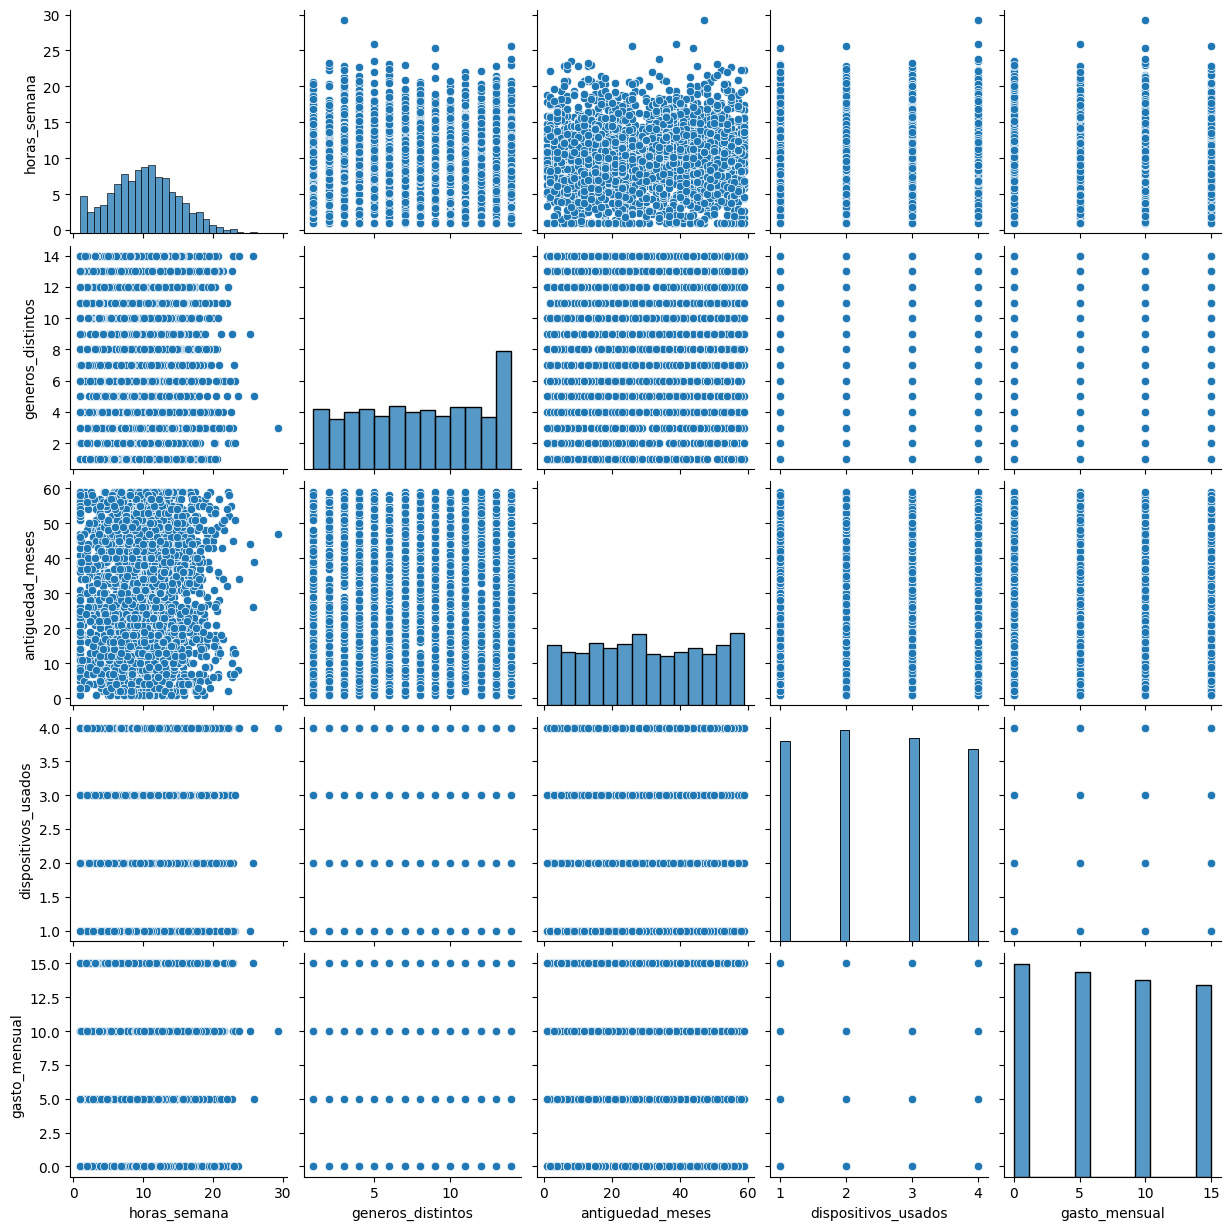

In [18]:
df.describe()
sns.pairplot(df)


Escalar

In [19]:
from sklearn.preprocessing import StandardScaler

# Separar variables (por claridad, aunque no haya target)
X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos a DataFrame para inspección
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled.head()



,horas_semana,generos_distintos,antiguedad_meses,dispositivos_usados,gasto_mensual
0,0.468473,0.116593,-0.489575,-0.434404,1.380143
1,-0.193646,1.610794,1.572412,-0.434404,-1.301324
2,0.625901,-0.879541,-0.607402,-0.434404,-1.301324
3,1.538657,1.610794,1.160015,1.373901,0.486321
4,-0.293633,-1.626641,0.747618,1.373901,1.380143


Método del codo

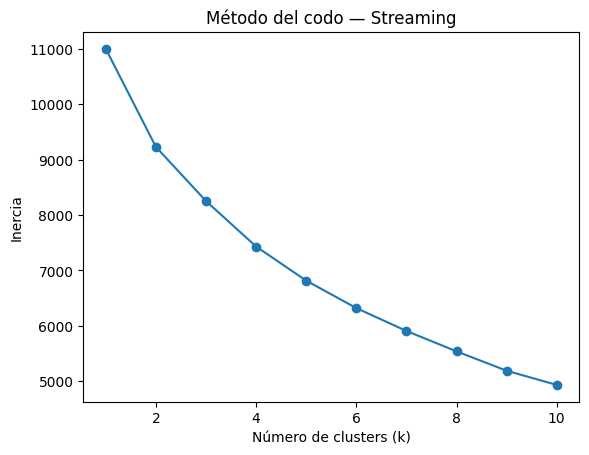

In [20]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)  # ⚠️ USAR DATOS ESCALADOS
    inertia.append(km.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo — Streaming")
plt.show()


Modelo final

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df["cluster"] = clusters
df.head()



,horas_semana,generos_distintos,antiguedad_meses,dispositivos_usados,gasto_mensual,cluster
0,12.483571,8,22,2,15,3
1,9.308678,14,57,2,0,0
2,13.238443,4,20,2,0,2
3,17.615149,14,50,4,10,3
4,8.829233,1,43,4,15,1


Perfil de usuarios

In [22]:
perfil_clusters = df.groupby("cluster").mean()
perfil_clusters



,horas_semana,generos_distintos,antiguedad_meses,dispositivos_usados,gasto_mensual
cluster,,,,,
0,9.474409,10.666096,30.503425,2.510274,2.037671
1,10.476260,4.164384,29.882583,3.573386,7.857143
2,10.517419,4.183246,30.387435,1.431065,6.980803
3,10.543187,10.932331,30.424812,2.528195,12.800752


Visualización

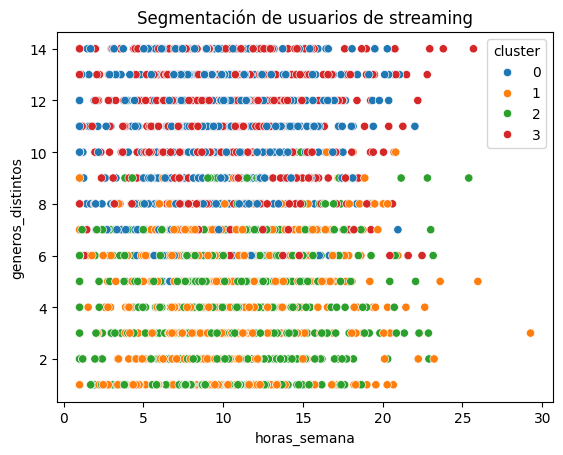

In [23]:
plt.figure()
sns.scatterplot(
    data=df,
    x="horas_semana",
    y="generos_distintos",
    hue="cluster",
    palette="tab10"
)
plt.title("Segmentación de usuarios de streaming")
plt.show()

